In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from data_loader import load_weekly_data, load_supplementary
input_data, output_data = load_weekly_data()

In [4]:
# Clean tracking data
# Clean orientation and direction
input_data["o_clean"] = (-(input_data["o"] - 90)) % 360
input_data["dir_clean"] = (-(input_data["dir"] - 90)) % 360
# Set x on same scale
input_data["x_clean"] = np.where(
      input_data["play_direction"] == "left",
      120 - input_data["x"],
      input_data[
          "x"
      ], 
  )
# y, s, a alreday clean
input_data["y_clean"] = input_data["y"]
input_data["s_clean"] = input_data["s"]
input_data["a_clean"] = input_data["a"]
# Clean orientation based on play direction
input_data["o_clean"] = np.where(
    input_data["play_direction"] == "left", 180 - input_data["o_clean"], input_data["o_clean"]
)
# Clean orientation, direction, vx, and vy
input_data["o_clean"] = (input_data["o_clean"] + 360) % 360 
input_data["dir_clean"] = (input_data["dir_clean"] + 360) % 360
input_data["dir_radians"] = np.radians(input_data["dir_clean"])
input_data["v_x"] = input_data["s_clean"] * np.cos(input_data["dir_radians"])
input_data["v_y"] = input_data["s_clean"] * np.sin(input_data["dir_radians"])

In [5]:
input_data.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,1,211.76,127.60,52.33,36.94,0.09,0.39,2.227040,-0.054913,0.071306
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,1,213.95,249.11,52.33,36.94,0.04,0.61,4.347790,-0.014263,-0.037371
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,1,209.40,302.45,52.33,36.93,0.12,0.73,5.278748,0.064388,-0.101263
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,1,205.75,318.60,52.35,36.92,0.23,0.81,5.560619,0.172526,-0.152102
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,1,205.75,326.74,52.37,36.90,0.35,0.82,5.702689,0.292667,-0.191954


In [6]:
input_data["player_side"].value_counts()

player_side
Defense    2662657
Offense    2217922
Name: count, dtype: int64

In [7]:
input_data.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'wk',
       'o_clean', 'dir_clean', 'x_clean', 'y_clean', 's_clean', 'a_clean',
       'dir_radians', 'v_x', 'v_y'],
      dtype='object')

## PCA

In [8]:
# 
offense = input_data[input_data['player_side'] == 'Offense'].copy()

pre_snap = offense.loc[offense.groupby(['game_id', 'play_id', 'nfl_id'])['frame_id'].idxmin()]

feature_columns = ["x_clean", "y_clean", "s_clean", "a_clean", "o_clean", "dir_clean", "v_x", "v_y"]

X = pre_snap[feature_columns].values


In [9]:
offense.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
130,2023090700,101,False,53541,1,right,42,Amon-Ra St. Brown,6-1,195,...,1,15.28,359.30,40.61,19.12,0.00,0.00,6.270968,0.000000,-0.000000
131,2023090700,101,False,53541,2,right,42,Amon-Ra St. Brown,6-1,195,...,1,14.39,1.66,40.61,19.12,0.00,0.00,0.028972,0.000000,0.000000
132,2023090700,101,False,53541,3,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,14.58,40.62,19.12,0.02,0.38,0.254469,0.019356,0.005035
133,2023090700,101,False,53541,4,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,10.32,40.63,19.12,0.16,1.38,0.180118,0.157412,0.028663
134,2023090700,101,False,53541,5,right,42,Amon-Ra St. Brown,6-1,195,...,1,9.99,0.65,40.67,19.12,0.48,3.08,0.011345,0.479969,0.005445


PCA Components: 8
Explained variance (ratio): [0.17974374 0.1521004  0.1369034  0.12500335 0.12417982 0.11298002
 0.09809769 0.07099157]
Cluster counts:
 cluster
7    18315
1    17991
6    17553
0    16932
5     3134
3     2699
2     1142
4     1091
Name: count, dtype: int64


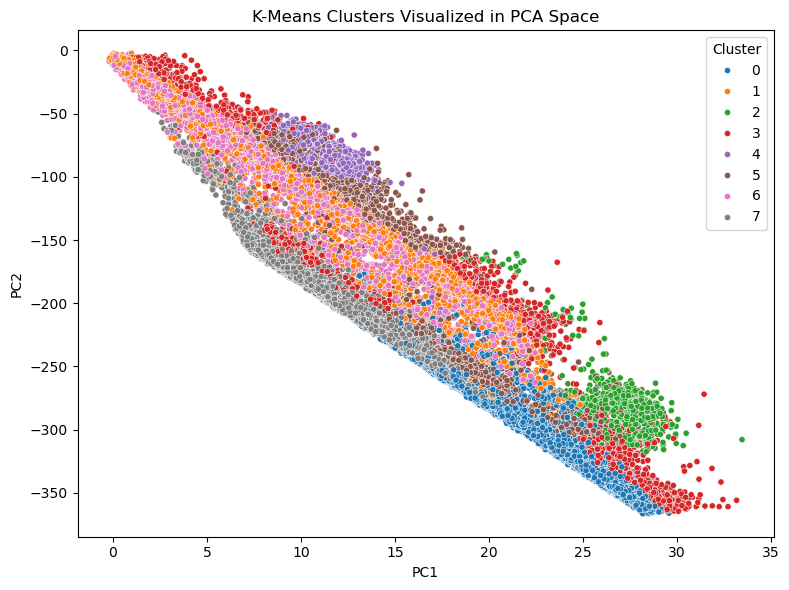

In [10]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  
    ('kmeans', KMeans(n_clusters=8, n_init=10, random_state=42))
])

pipe.fit(X)

pca = pipe.named_steps['pca']

labels = pipe.named_steps['kmeans'].labels_
pre_snap["cluster"] = labels

# stats

print("PCA Components:", pca.n_components_)
print("Explained variance (ratio):", pca.explained_variance_ratio_)
print("Cluster counts:\n", pre_snap["cluster"].value_counts())

X_pca = pca.transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette="tab10",
    s=20
)
plt.title("K-Means Clusters Visualized in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [11]:
cluster_summary = pre_snap.groupby("cluster")[feature_columns].mean()
cluster_summary

,x_clean,y_clean,s_clean,a_clean,o_clean,dir_clean,v_x,v_y
cluster,,,,,,,,
0,59.665639,28.735615,0.051120,0.202791,341.380896,273.490275,0.004669,-0.028023
1,63.156229,18.213343,0.049528,0.215758,24.734180,185.247564,-0.000016,-0.000453
2,53.931357,25.841471,6.012198,1.548678,274.317452,269.705377,-0.029775,-5.979709
3,53.976258,25.981445,0.771878,2.015695,181.840422,193.745587,0.410923,-0.048393
4,54.394592,27.798469,6.002887,1.545435,84.256022,90.170403,-0.021253,5.974146
5,53.498197,27.062387,0.745466,1.937562,183.127144,178.774234,-0.404385,0.026617
6,45.411322,33.124547,0.049561,0.193242,19.501352,174.747006,0.000113,0.003835
7,49.386815,27.497669,0.048304,0.209720,341.360644,91.628314,0.000751,0.022882


In [13]:
from sklearn.metrics import silhouette_score

sil_scores = []
K_values_sil = list(range(2, 11))

for k in K_values_sil:
    pipe.set_params(kmeans__n_clusters=k)
    pipe.fit(X)

    labels = pipe["kmeans"].labels_

    sil = silhouette_score(X, labels)

    sil_scores.append(sil)

In [17]:
sil_scores

[0.5964978431860586,
 0.36080922265480636,
 0.05239384080925968,
 -0.0571828683878478,
 -0.0947305229725968,
 -0.11846299745992692,
 0.04473713307336704,
 -0.0375102166841824,
 -0.022241919935220615]

In [15]:
import plotly.express as px

lines = list(range(2, 11))
fig = px.line(
    x=lines,
    y=sil_scores,
    markers=True,
    title="Silhouette Scores (Pipeline: StandardScaler + KMeans)",
    labels={"x": "Number of Clusters (K)", "y": "Silhouette Score"}
)

fig.update_layout(height=500, width=700)
fig.show()

In [16]:
# Elbow 

K_values = list(range(1, 11))
wcss = []

for k in K_values:
    pipe.set_params(kmeans__n_clusters=k)
    pipe.fit(X)
    inertia = pipe["kmeans"].inertia_
    wcss.append(inertia)


fig = px.line(
    x=K_values,
    y=wcss,
    markers=True,
    title="Elbow Plot (Pipeline: StandardScaler + KMeans)",
    labels={"x": "Number of Clusters (K)", "y": "WCSS / Inertia"}
)

fig.update_layout(height=500, width=700)
fig.show()

In [18]:
wcss

[630855.9999999994,
 551438.54948092,
 471368.64483789954,
 400163.93710699753,
 369232.42387105525,
 336780.1556552497,
 311925.66054958384,
 291508.43308068736,
 271488.7556982545,
 254983.26985821503]

# Cluster Interpretations